Teams building with multimodal data stitch together 5-8 services: a database, a vector store, blob storage, an orchestrator, a RAG framework, an experiment tracker, custom retry logic. **Pixeltable replaces them with one table where every modality is a first-class column type.**

| Instead of ... | Pixeltable gives you ... |
|---|---|
| PostgreSQL / MySQL | `pxt.create_table()` with schema in Python, versioned automatically |
| Pinecone / Weaviate / Qdrant | `add_embedding_index()` in one line, always in sync |
| S3 / boto3 / blob storage | `pxt.Image`, `Video`, `Audio`, `Document` as native types |
| Airflow / Prefect / Celery | Computed columns that trigger on insert, no orchestrator |
| LangChain / LlamaIndex | `@pxt.query` + `.similarity()` with computed column chaining |

Pixeltable is fully extensible through `@pxt.udf` (custom functions), `@pxt.uda` (custom aggregations), and `@pxt.query` (reusable queries). We provide the data infrastructure for multimodal AI; you bring your logic, your models, your domain.

### Built for AI-first development

Pixeltable integrates with [20+ AI providers](https://docs.pixeltable.com/integrations/frameworks) (OpenAI, Anthropic, Gemini, HuggingFace, Ollama, Bedrock, ...) and is designed to work with AI coding assistants. The codebase is fully declarative Python, so LLMs can generate correct Pixeltable code without complex glue logic.

- **[Pixeltable Skill](https://github.com/pixeltable/pixeltable-skill)** for Cursor, Claude Code, Copilot, Windsurf; `npx skills add pixeltable/pixeltable-skill`
- **[llms.txt](https://docs.pixeltable.com/llms.txt)** for full docs in LLM-readable format
- **[MCP Server](https://github.com/pixeltable/mcp-server-pixeltable-developer)** for interactive table exploration
- **[Pixeltable Starter Kit](https://github.com/pixeltable/pixeltable-starter-kit)** for a production reference app (FastAPI + React)

```bash
pip install pixeltable google-genai 'fastapi[standard]'
pip install torch transformers  # optional, for object detection
```

In [9]:
import getpass
import logging
import os
import warnings

warnings.filterwarnings('ignore')
logging.getLogger('asyncio').setLevel(logging.CRITICAL)
logging.getLogger('huggingface_hub').setLevel(logging.CRITICAL)

if 'GEMINI_API_KEY' not in os.environ and 'GOOGLE_API_KEY' not in os.environ:
    os.environ['GEMINI_API_KEY'] = getpass.getpass('Gemini API Key: ')

import pixeltable as pxt
from pixeltable.functions import gemini

BASE_URL = 'https://raw.githubusercontent.com/pixeltable/pixeltable/release/docs/resources'

## 1. Store: Multimodal Tables

Video, audio, images, and documents are first-class column types, not opaque blobs in S3. `pip install pixeltable` is all you need.

In [10]:
from pixeltable.functions.uuid import uuid7

pxt.drop_dir('demo', force=True, if_not_exists='ignore')
pxt.create_dir('demo')

videos = pxt.create_table(
    'demo/videos',
    {'id': pxt.String, 'video': pxt.Video, 'title': pxt.String},
    primary_key='id',
)
videos

Created directory 'demo'.
Created table 'videos'.


table 'demo/videos'

 Column Name    Type  Source Computed With Comment
--------------------------------------------------
       video   Video  videos                      
       title  String  videos

## 2. Orchestrate: AI as Computed Columns

No orchestrator, no DAG. Add a computed column and Pixeltable calls Gemini on every insert, caches results, retries failures, and keeps embeddings in sync.

In [11]:
videos.add_computed_column(
    response=gemini.generate_content(
        [videos.video, 'Describe this video in detail.'], model='gemini-3-flash-preview'
    )
)

videos.add_computed_column(
    description=videos.response.candidates[0].content.parts[0].text.astype(pxt.String)
)

videos.add_embedding_index('description', embedding=gemini.embed_content.using(model='gemini-embedding-2-preview'))

Added 0 column values with 0 errors in 0.01 s
Added 0 column values with 0 errors in 0.02 s


## 3. Insert: One Call Triggers the Full Pipeline

A single `insert()` downloads the videos, runs Gemini analysis, extracts the description text, and computes embeddings. Open the **Dashboard** to watch it happen in real time.

In [12]:
videos.insert([
    {'id': 'bangkok', 'video': f'{BASE_URL}/bangkok.mp4', 'title': 'Bangkok Street Tour'},
    {'id': 'pursuit', 'video': f'{BASE_URL}/The-Pursuit-of-Happiness-Video-Extract.mp4', 'title': 'The Pursuit of Happiness'},
])

ERROR:asyncio:Fatal error on SSL transport
protocol: <asyncio.sslproto.SSLProtocol object at 0x169a372b0>
transport: <_SelectorSocketTransport closing fd=85>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/pxt/lib/python3.10/asyncio/selector_events.py", line 924, in write
    n = self._sock.send(data)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/miniconda3/envs/pxt/lib/python3.10/asyncio/sslproto.py", line 690, in _process_write_backlog
    self._transport.write(chunk)
  File "/opt/miniconda3/envs/pxt/lib/python3.10/asyncio/selector_events.py", line 930, in write
    self._fatal_error(exc, 'Fatal write error on socket transport')
  File "/opt/miniconda3/envs/pxt/lib/python3.10/asyncio/selector_events.py", line 725, in _fatal_error
    self._force_close(exc)
  File "/opt/miniconda3/envs/pxt/lib/python3.10/asyncio/selector_events.py", line 737, in _force_close
 

Inserted 2 rows with 0 errors in 25.07 s (0.08 rows/s)


2 rows inserted.

In [13]:
videos = pxt.get_table('demo/videos')
videos.select(videos.title, videos.description).collect()

title,description
Bangkok Street Tour,"A high-angle, long shot of a busy multi-lane city street in Bangkok, Thailand. The street is filled with a variety of vehicles including colorful taxis, private cars, motorcycles, a white pickup truck, and a traditional Thai tuk-tuk. The traffic flows in both directions, with vehicles moving towards and away from the camera. On the left side of the street, there are several large buildings with colorful advertisements, while on the right, there are trees and a modern building complex with festive pink and white tents. In the distance, a pedestrian bridge spans across the road, and more tall buildings can be seen in the city skyline. The overall scene captures the bustling urban life of the city during the daytime."
The Pursuit of Happiness,"This clip from the film ""The Pursuit of Happyness"" captures a pivotal moment for the protagonist, Chris Gardner. The scene unfolds in the hallway of an office building. Chris Gardner (played by Will Smith), dressed in a grey work uniform that resembles a garbage man's outfit, is approached by an executive, Mr. Twistle. Twistle, wearing a dark suit and light blue tie, praises Chris's performance in what was likely a high-stakes interview or meeting, noting how impressive it was that he su ...... hris graciously thanks him, addressing him as ""Mr. Twistle."" In a sign of burgeoning professional respect and a step towards a closer relationship, the executive invites Chris to call him ""Jay"" and tells him they'll speak again soon before walking away. The scene is set in a corporate environment with wood-paneled walls and several other office workers in the background. Chris's expression is one of relief and quiet triumph, highlighting the significance of this interaction in his journey."


## 4. Retrieve: Semantic Search

Search by meaning, not keywords. The embedding index stays in sync automatically; no separate vector DB to manage.

In [14]:
sim = videos.description.similarity(string='street food')

# Filter + rank in one expression
videos.where(videos.description != None).order_by(sim, asc=False).limit(5).select(
    videos.title, videos.description, sim
).collect()

title,description,similarity
The Pursuit of Happiness,"This clip from the film ""The Pursuit of Happyness"" captures a pivotal moment for the protagonist, Chris Gardner. The scene unfolds in the hallway of an office building. Chris Gardner (played by Will Smith), dressed in a grey work uniform that resembles a garbage man's outfit, is approached by an executive, Mr. Twistle. Twistle, wearing a dark suit and light blue tie, praises Chris's performance in what was likely a high-stakes interview or meeting, noting how impressive it was that he su ...... hris graciously thanks him, addressing him as ""Mr. Twistle."" In a sign of burgeoning professional respect and a step towards a closer relationship, the executive invites Chris to call him ""Jay"" and tells him they'll speak again soon before walking away. The scene is set in a corporate environment with wood-paneled walls and several other office workers in the background. Chris's expression is one of relief and quiet triumph, highlighting the significance of this interaction in his journey.",0.395
Bangkok Street Tour,"A high-angle, long shot of a busy multi-lane city street in Bangkok, Thailand. The street is filled with a variety of vehicles including colorful taxis, private cars, motorcycles, a white pickup truck, and a traditional Thai tuk-tuk. The traffic flows in both directions, with vehicles moving towards and away from the camera. On the left side of the street, there are several large buildings with colorful advertisements, while on the right, there are trees and a modern building complex with festive pink and white tents. In the distance, a pedestrian bridge spans across the road, and more tall buildings can be seen in the city skyline. The overall scene captures the bustling urban life of the city during the daytime.",0.106


## 5. Experiment on Media Data

Experimenting on media is usually painful: extract frames, save to disk, run a model, parse output, match back to source. In Pixeltable it's one expression. Here we extract a frame, run DETR object detection, and draw labeled bounding boxes, all at query time. Change `timestamp` and re-run to explore different frames instantly.

ERROR:asyncio:Fatal error on SSL transport
protocol: <asyncio.sslproto.SSLProtocol object at 0x169abeb60>
transport: <_SelectorSocketTransport closing fd=84>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/pxt/lib/python3.10/asyncio/selector_events.py", line 924, in write
    n = self._sock.send(data)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/miniconda3/envs/pxt/lib/python3.10/asyncio/sslproto.py", line 690, in _process_write_backlog
    self._transport.write(chunk)
  File "/opt/miniconda3/envs/pxt/lib/python3.10/asyncio/selector_events.py", line 930, in write
    self._fatal_error(exc, 'Fatal write error on socket transport')
  File "/opt/miniconda3/envs/pxt/lib/python3.10/asyncio/selector_events.py", line 725, in _fatal_error
    self._force_close(exc)
  File "/opt/miniconda3/envs/pxt/lib/python3.10/asyncio/selector_events.py", line 737, in _force_close
 

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


title,annotated
Bangkok Street Tour,
The Pursuit of Happiness,

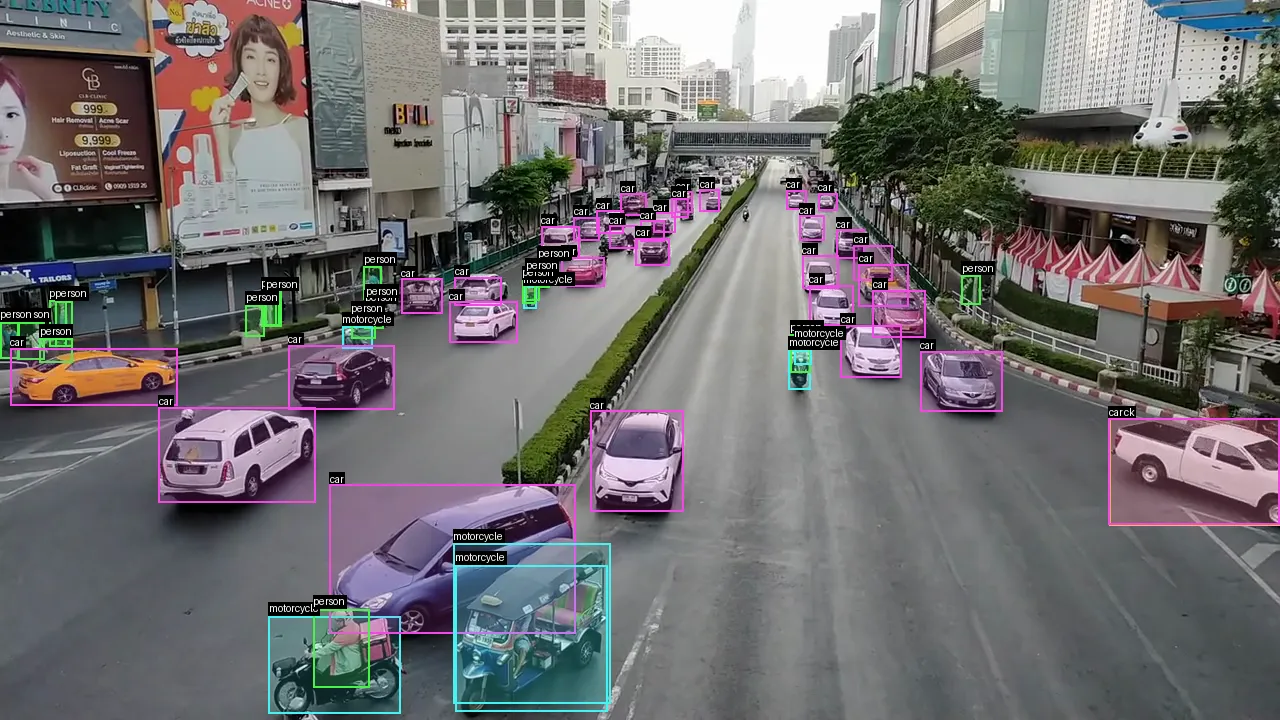
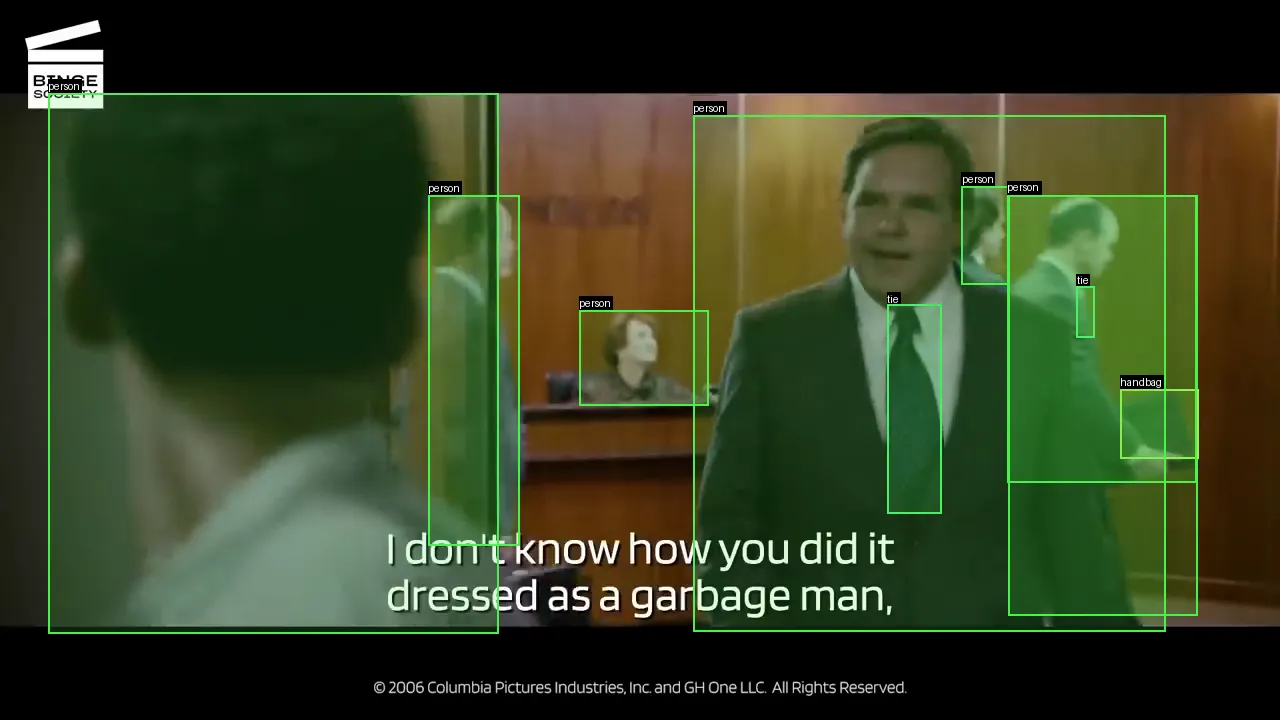

In [15]:
from pixeltable.functions import huggingface
from pixeltable.functions.vision import bboxes_draw

frame = videos.video.extract_frame(timestamp=2.0)
detections = huggingface.detr_for_object_detection(frame, model_id='facebook/detr-resnet-50')

videos.select(
    videos.title,
    annotated=bboxes_draw(
        frame,
        boxes=detections.boxes,
        labels=detections.label_text,
        fill=True,
        fill_alpha=0.15,
        width=2,
        font_size=14,
    ),
).collect()

## 6. Serve: Queries Become API Endpoints

Turn any `@pxt.query` into an HTTP endpoint with `FastAPIRouter`. No hand-written routes, no Pydantic models, no serialization code. In production, use `pxt serve service.toml`.

In [16]:
import fastapi
from fastapi.testclient import TestClient

from pixeltable.serving import FastAPIRouter


@pxt.query
def search_videos(query_text: str, limit: int = 5):
    sim = videos.description.similarity(string=query_text)
    return videos.order_by(sim, asc=False).limit(limit).select(videos.title, videos.description, sim)


app = fastapi.FastAPI()
router = FastAPIRouter()
router.add_query_route(path='/search', query=search_videos)
router.add_insert_route(
    videos, path='/ingest', inputs=['id', 'video', 'title'], outputs=['title', 'description']
)
router.add_delete_route(videos, path='/delete')
app.include_router(router)

client = TestClient(app)

In [17]:
resp = client.post('/search', json={'query_text': 'street food', 'limit': 2})
resp.json()

{'rows': [{'title': 'The Pursuit of Happiness',
   'description': 'This clip from the film "The Pursuit of Happyness" captures a pivotal moment for the protagonist, Chris Gardner. \n\nThe scene unfolds in the hallway of an office building. Chris Gardner (played by Will Smith), dressed in a grey work uniform that resembles a garbage man\'s outfit, is approached by an executive, Mr. Twistle. \n\nTwistle, wearing a dark suit and light blue tie, praises Chris\'s performance in what was likely a high-stakes interview or meeting, noting how impressive it was that he succeeded despite his informal attire. Chris graciously thanks him, addressing him as "Mr. Twistle." In a sign of burgeoning professional respect and a step towards a closer relationship, the executive invites Chris to call him "Jay" and tells him they\'ll speak again soon before walking away. \n\nThe scene is set in a corporate environment with wood-paneled walls and several other office workers in the background. Chris\'s expre

In [18]:
resp = client.post('/ingest', json={'id': 'test-1', 'video': f'{BASE_URL}/bangkok.mp4', 'title': 'Test Upload'})
resp.json()

Inserted 1 row with 0 errors in 13.76 s (0.07 rows/s)


{'title': 'Test Upload',
 'description': 'The video shows a high-angle, wide shot of a bustling multi-lane street in what appears to be Bangkok, Thailand, likely near the Pratunam area. The camera is stationary, overlooking a wide road with traffic moving in both directions.\n\n### **Traffic and Vehicles:**\nA steady flow of various vehicles fills the road. Prominent among them are the iconic colorful taxis of Bangkok—bright pink and yellow-green. Numerous white, silver, and black sedans and SUVs move along the lanes. Several motorcycles and scooters weave through the traffic, including one with a large pink delivery bag on the back. Near the bottom center, a blue hatchback and a traditional three-wheeled tuk-tuk are positioned on the left side of the outbound lanes. A white pickup truck is also visible on the right side of the street.\n\n### **Surrounding Environment:**\nThe street is flanked by tall commercial buildings and shopping centers. \n*   **On the left side:** Large, vibrant

In [ ]:
resp = client.post('/delete', json={'id': 'test-1'})
resp.json()

## Bonus: Cloud Storage (Optional)

Every Pixeltable Cloud account includes a free managed storage bucket. Set two env vars and all computed media flows to the cloud instead of local disk. No S3 account, no bucket creation.

```toml
# ~/.pixeltable/config.toml
[pixeltable]
api_key = "your-pixeltable-cloud-api-key"
output_media_dest = "pxtfs://yourorg:yourdb/home"
```

Or configure at runtime (skip by pressing Enter if you don't have a key yet):

In [ ]:
if 'PIXELTABLE_API_KEY' not in os.environ:
    key = getpass.getpass('Pixeltable Cloud API Key (Enter to skip): ')
    if key:
        os.environ['PIXELTABLE_API_KEY'] = key

if os.environ.get('PIXELTABLE_API_KEY'):
    # Replace with your org:db slug
    os.environ['PIXELTABLE_OUTPUT_MEDIA_DEST'] = 'pxtfs://yourorg:yourdb/home'
    print(f'Cloud storage enabled: {os.environ["PIXELTABLE_OUTPUT_MEDIA_DEST"]}')
else:
    print('Skipped. Using local storage.')

## What Pixeltable Does

Everything you saw in this demo is part of a broader system. Here's the full picture:

| You write | Pixeltable does |
|---|---|
| `pxt.Image`, `pxt.Video`, `pxt.Document` columns | Stores media, handles formats, caches from URLs |
| `add_computed_column(fn(...))` | Runs incrementally, caches results, retries failures |
| `add_embedding_index(column)` | Manages vector storage, keeps index in sync |
| `@pxt.udf` / `@pxt.query` | Creates reusable functions with dependency tracking |
| `table.insert(...)` | Triggers all dependent computations automatically |
| `t.sample(5).select(t.text, summary=udf(t.text))` | Experiments on a sample; nothing stored, calls parallelized and cached |
| `table.select(...).collect()` | Returns structured + unstructured data together |
| *(nothing; it's automatic)* | Versions all data and schema changes for time-travel |

### The ten primitives

| Primitive | What it gives you |
|---|---|
| **Store** | Multimodal tables with native `Image`, `Video`, `Audio`, `Document` types |
| **Orchestrate** | AI providers as computed columns; trigger on insert, no DAG |
| **Iterate** | Views with iterators for frames, chunks, segments |
| **Index** | Embedding indexes that stay in sync with the data |
| **Extend** | `@pxt.udf` for custom logic, any Python library |
| **Agents & Tools** | `@pxt.tools` + `invoke_tools()` for tool-calling agents as computed columns |
| **Query & Experiment** | `.sample()`, `.select()` with on-the-fly expressions; prototype to production |
| **Serve** | `@pxt.query` + `FastAPIRouter` or `pxt serve` for HTTP endpoints |
| **Version** | Automatic versioning, `history()`, `revert()`, time-travel |
| **Import/Export** | CSV, JSON, Parquet, PyTorch, COCO, LanceDB, SQL, Hugging Face |

### Go deeper

- **[10-Minute Tour](https://docs.pixeltable.com/overview/ten-minute-tour)** -- Interactive walkthrough of all core concepts
- **[Pixeltable Starter Kit](https://github.com/pixeltable/pixeltable-starter-kit)** -- Full-stack reference app: document/image/video processing, cross-modal search, and a tool-calling agent, all built on computed columns
- **[Cookbooks](https://docs.pixeltable.com/howto/cookbooks)** -- 50+ recipes for video, audio, images, documents, agents, RAG, and more
- **[Documentation](https://docs.pixeltable.com/)** -- Tutorials, deployment guides, API reference
- **[GitHub](https://github.com/pixeltable/pixeltable)** -- Apache 2.0, free, no account required